# Sistem Rekomendasi Skyline : Better Service, Best Satisfaction

Dashboard Streamlit PoC ini menerapkan pendekatan hybrid recommendation system dengan ensemble-based machine learning model, di mana CatBoost digunakan untuk memprediksi tingkat kepuasan atau confidence rekomendasi, kemudian hasil prediksi tersebut dikombinasikan dengan rule-based logic, segment analysis, dan business impact simulation untuk menghasilkan rekomendasi layanan penerbangan yang personal dan relevan bagi kebutuhan bisnis B2B maskapai.

In [1]:
import pandas as pd
import os
import json
import warnings
from pathlib import Path
import numpy as np

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

df = pd.read_csv("D:\PENS-EEPIS\SDT A Semester 4 2026\Sistem Rekomendasi\Projek Mini\data\Raw\Airline Quality Ratings.csv")
print(df.shape)

(129880, 24)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

## Keterangan Fitur:

ID: Passenger ID

Gender: Passenger gender

Age: Passenger age

Customer Type: The customer type

Type of Travel: Purpose of the flight of the passengers

Class: Travel class in the plane of the passengers

Flight Distance: Flight distance

Departure Delay: Minutes delayed when departure

Arrival Delay: Minutes delayed when Arrival

Departure & Arrival Time Сonvenience: Convenience of departure and arrival times for passengers

Ease of Online Booking: Easy to book

Check-in Service: Ease of registration

Online Boarding: Convenience of online registration

Gate Location: Gate Location Estimation

On-board Service: Service on board

Seat Comfort: Comfortable seating

Leg Room Service: Leg room service level

Cleanliness: Cleanliness level

Food and Drink: Quality of food and drinks

In-flight Service: Level of service on board

In-flight Wifi Service: Wifi quality level on board

In-flight Entertainment: Rating of in-flight entertainment

Baggage Handling: Opinion on baggage handling

Satisfaction: Airline satisfaction level

In [4]:
df.isnull().sum()
df.fillna(0, inplace=True)

In [5]:
# Pembagian fitur berdasarkan kategori

customer_features = [
    'Gender',
    'Age',
    'Customer Type',
    'Type of Travel',
    'Class'
]

service_quality_features = [
    'Departure and Arrival Time Convenience',
    'Ease of Online Booking',
    'Check-in Service',
    'Online Boarding',
    'Gate Location',
    'On-board Service',
    'Seat Comfort',
    'Leg Room Service',
    'Cleanliness',
    'Food and Drink',
    'In-flight Service',
    'In-flight Wifi Service',
    'In-flight Entertainment',
    'Baggage Handling'
]

operational_features = [
    'Flight Distance',
    'Departure Delay',
    'Arrival Delay'
]

target_col = 'Satisfaction'

features = customer_features + service_quality_features + operational_features

categorical_features = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]

numerical_features = [
    col for col in features if col not in categorical_features
]

print("Total features:", len(features))
print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Total features: 22
Categorical features: ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Numerical features: ['Age', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling', 'Flight Distance', 'Departure Delay', 'Arrival Delay']


In [6]:
# Target Variable

print("=" * 50)
print("TARGET VARIABLE")
print("=" * 50)

print(f"\nValue counts untuk target variable '{target_col}':")
print(df[target_col].value_counts())

print(f"\nPersentase target variable '{target_col}':")
print(df[target_col].value_counts(normalize=True) * 100)


TARGET VARIABLE

Value counts untuk target variable 'Satisfaction':
Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64

Persentase target variable 'Satisfaction':
Satisfaction
Neutral or Dissatisfied    56.553742
Satisfied                  43.446258
Name: proportion, dtype: float64


## EDA

In [8]:
# ============================================================
# 4. EDA - BASIC OVERVIEW
# ============================================================

print("Dataset info:")
display(df.info())

print("\nMissing values:")
display(df[features + [target_col]].isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df[target_col].value_counts())

print("\nTarget percentage:")
display((df[target_col].value_counts(normalize=True) * 100).round(2))

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129880 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking        

None


Missing values:


Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment                   0
Baggage Handling                          0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Satisfaction                    


Duplicate rows: 0

Target distribution:


Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64


Target percentage:


Satisfaction
Neutral or Dissatisfied    56.55
Satisfied                  43.45
Name: proportion, dtype: float64

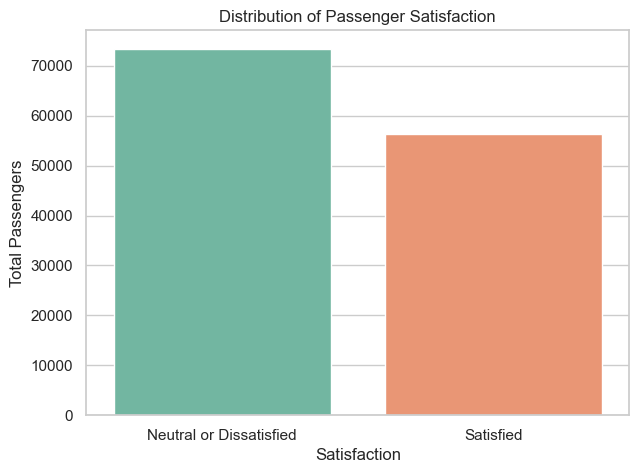

In [10]:
# ============================================================
# 5. EDA - TARGET VISUALIZATION
# ============================================================
import seaborn as sns
sns.set(style="whitegrid")
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x=target_col,
    palette="Set2"
)

plt.title("Distribution of Passenger Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Total Passengers")
plt.show()

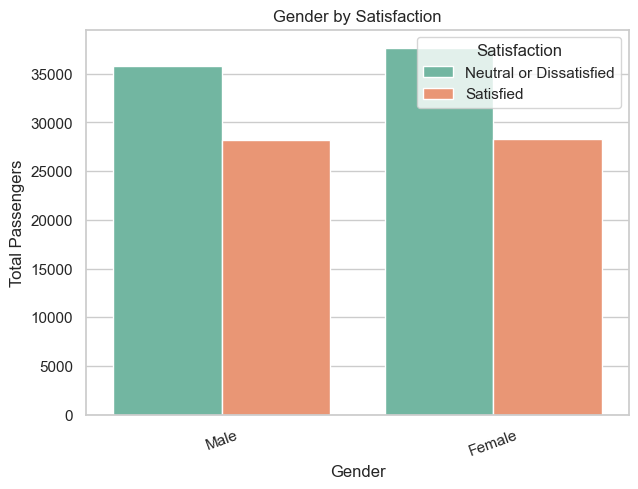

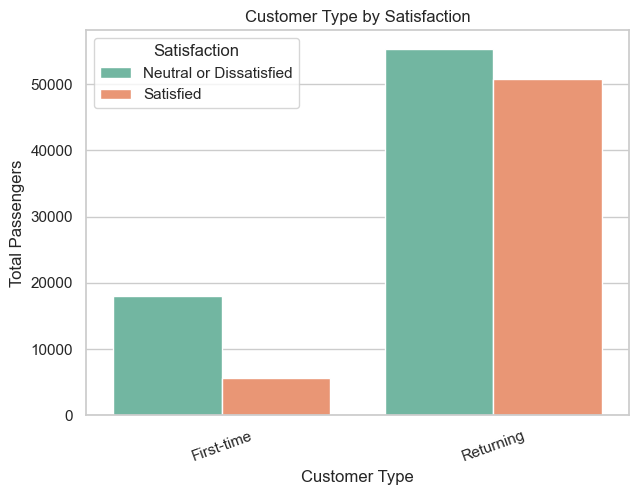

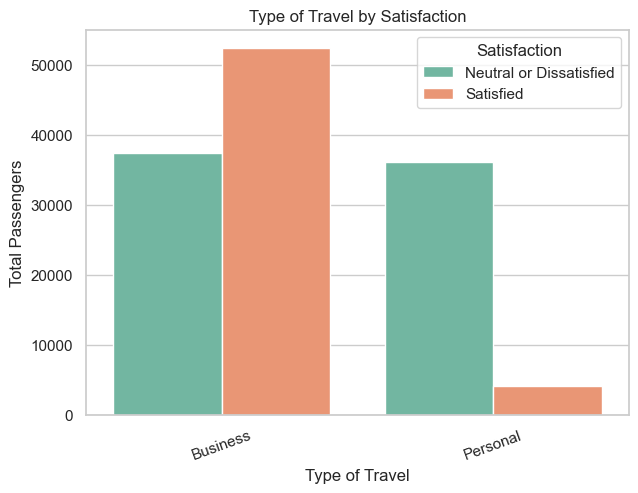

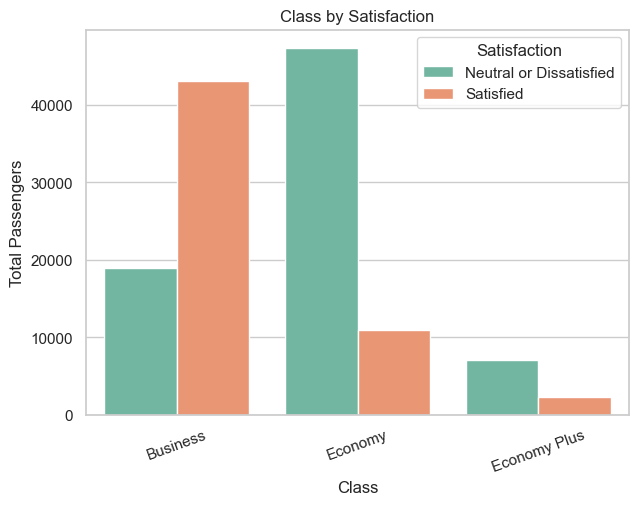

In [11]:
# ============================================================
# 6. EDA - CUSTOMER FEATURES
# ============================================================

for col in ["Gender", "Customer Type", "Type of Travel", "Class"]:
    plt.figure(figsize=(7, 5))
    sns.countplot(
        data=df,
        x=col,
        hue=target_col,
        palette="Set2"
    )

    plt.title(f"{col} by Satisfaction")
    plt.xlabel(col)
    plt.ylabel("Total Passengers")
    plt.xticks(rotation=20)
    plt.legend(title="Satisfaction")
    plt.show()

Satisfaction,Neutral or Dissatisfied,Satisfied,Gap
Online Boarding,2.658621,4.025856,1.367235
In-flight Entertainment,2.892433,3.964202,1.071769
Seat Comfort,3.037998,3.966417,0.928420
On-board Service,3.019537,3.856171,0.836634
Leg Room Service,2.990443,3.820054,0.829611
Cleanliness,2.932800,3.746509,0.813709
In-flight Wifi Service,2.398423,3.158609,0.760186
Check-in Service,3.042967,3.649004,0.606037
Baggage Handling,3.374912,3.966914,0.592002
In-flight Service,3.389601,3.970990,0.581388


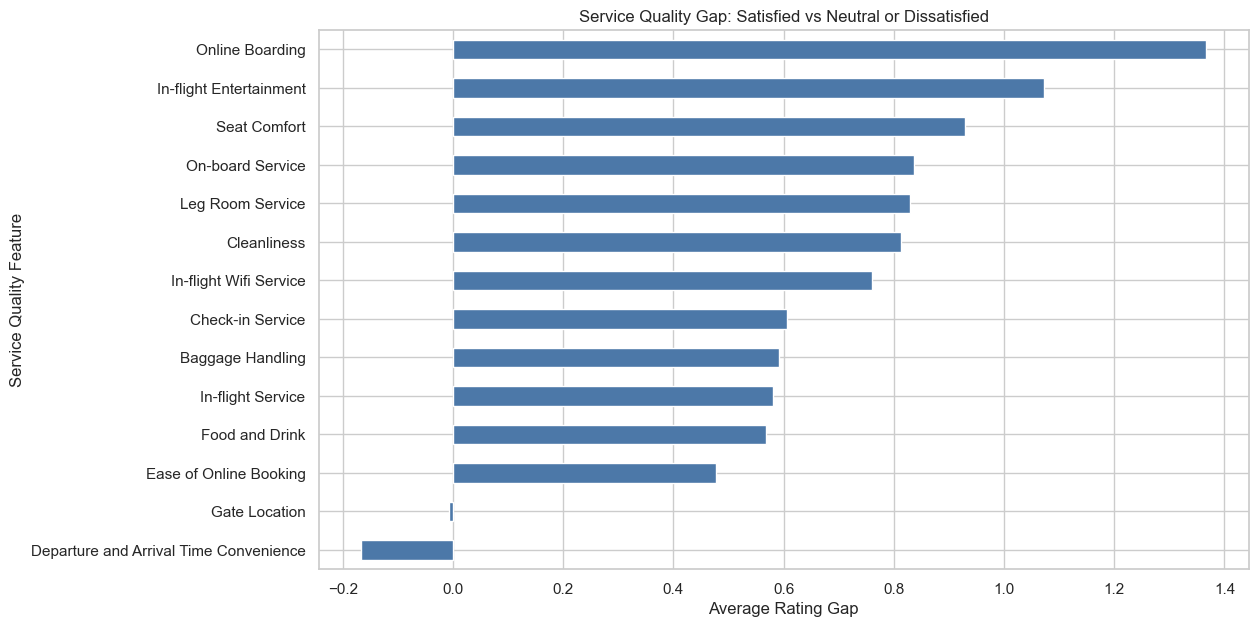

In [12]:
# ============================================================
# 7. EDA - SERVICE QUALITY IMPACT
# ============================================================

service_mean = df.groupby(target_col)[service_quality_features].mean().T
service_mean["Gap"] = (
    service_mean["Satisfied"] - service_mean["Neutral or Dissatisfied"]
)

display(service_mean.sort_values("Gap", ascending=False))

plt.figure(figsize=(12, 7))
service_mean["Gap"].sort_values().plot(kind="barh", color="#4C78A8")

plt.title("Service Quality Gap: Satisfied vs Neutral or Dissatisfied")
plt.xlabel("Average Rating Gap")
plt.ylabel("Service Quality Feature")
plt.show()

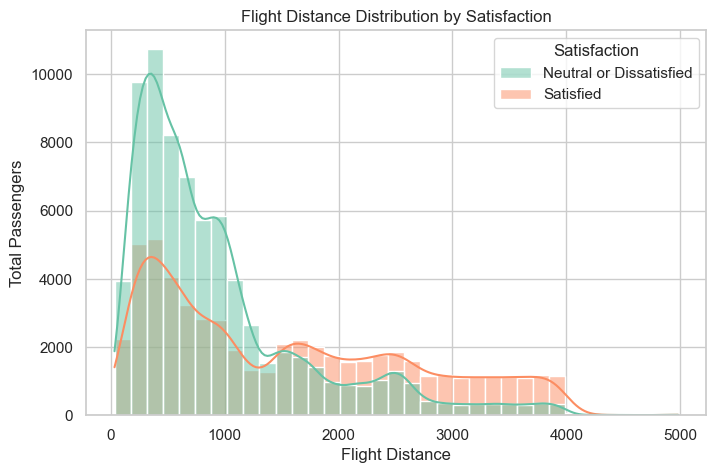

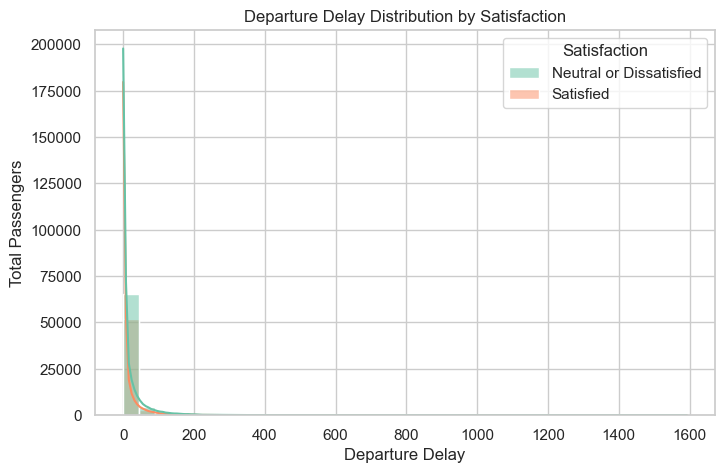

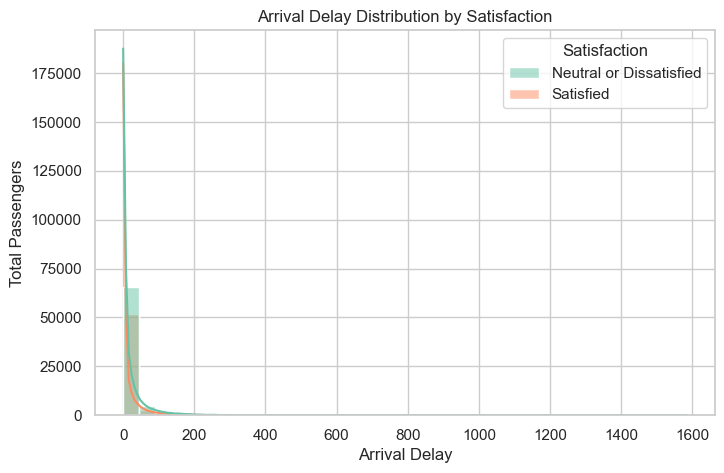

In [13]:
# ============================================================
# 8. EDA - OPERATIONAL FEATURES
# ============================================================

for col in operational_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        bins=35,
        kde=True,
        palette="Set2"
    )

    plt.title(f"{col} Distribution by Satisfaction")
    plt.xlabel(col)
    plt.ylabel("Total Passengers")
    plt.show()

## Preprocessing

In [14]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split

df_model = df.copy()

# Drop ID karena hanya identifier, bukan fitur prediktif.
if "ID" in df_model.columns:
    df_model = df_model.drop(columns=["ID"])

# Pastikan hanya memakai kolom yang dibutuhkan.
df_model = df_model[features + [target_col]]

# Handle missing values.
for col in categorical_features:
    df_model[col] = df_model[col].fillna("Unknown").astype(str)

for col in numerical_features:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Encode target.
target_mapping = {
    "Neutral or Dissatisfied": 0,
    "Satisfied": 1
}

inverse_target_mapping = {
    0: "Neutral or Dissatisfied",
    1: "Satisfied"
}

df_model["target_encoded"] = df_model[target_col].map(target_mapping)

if df_model["target_encoded"].isnull().sum() > 0:
    raise ValueError("Ada label target yang belum masuk mapping.")

X = df_model[features]
y = df_model["target_encoded"]

print("X shape:", X.shape)
print("y distribution:")
display(y.value_counts())


X shape: (129880, 22)
y distribution:


target_encoded
0    73452
1    56428
Name: count, dtype: int64

### Splitting

In [15]:
# ============================================================
# 10. TRAIN VALID TEST SPLIT
# ============================================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test :", X_test.shape)

Train: (83123, 22)
Valid: (20781, 22)
Test : (25976, 22)


In [22]:
# ============================================================
# 11. CATBOOST POOL
# ============================================================

train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=categorical_features
)

valid_pool = Pool(
    data=X_valid,
    label=y_valid,
    cat_features=categorical_features
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=categorical_features
)

cat_features = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]


## Model Training

In [17]:
# ============================================================
# 12. BASELINE CATBOOST MODEL
# ============================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

baseline_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    random_seed=RANDOM_STATE,
    verbose=100,
    allow_writing_files=False
)

baseline_model.fit(
    train_pool,
    eval_set=valid_pool,
    early_stopping_rounds=50,
    use_best_model=True
)


0:	test: 0.9606271	best: 0.9606271 (0)	total: 198ms	remaining: 1m 39s
100:	test: 0.9921969	best: 0.9921969 (100)	total: 5.03s	remaining: 19.9s
200:	test: 0.9939874	best: 0.9939874 (200)	total: 9.96s	remaining: 14.8s
300:	test: 0.9945263	best: 0.9945263 (300)	total: 14.9s	remaining: 9.87s
400:	test: 0.9948388	best: 0.9948388 (400)	total: 20s	remaining: 4.93s
499:	test: 0.9949771	best: 0.9949771 (499)	total: 25s	remaining: 0us

bestTest = 0.9949770929
bestIteration = 499



CatBoostClassifier(allow_writing_files=False, depth=6, eval_metric='AUC', iterations=500, l2_leaf_reg=3, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [20]:
# ============================================================
# 13. BASELINE EVALUATION
# ============================================================

y_pred_baseline = baseline_model.predict(test_pool).astype(int)
y_proba_baseline = baseline_model.predict_proba(test_pool)[:, 1]

baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_baseline),
    "precision": precision_score(y_test, y_pred_baseline),
    "recall": recall_score(y_test, y_pred_baseline),
    "f1_score": f1_score(y_test, y_pred_baseline),
    "roc_auc": roc_auc_score(y_test, y_proba_baseline)
}

baseline_metrics = {
    key: round(value, 4)
    for key, value in baseline_metrics.items()
}

display(baseline_metrics)

print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=["Neutral or Dissatisfied", "Satisfied"]
))

print(confusion_matrix(
    y_test,
    y_pred_baseline
))

{'accuracy': 0.9646,
 'precision': 0.9733,
 'recall': 0.9444,
 'f1_score': 0.9586,
 'roc_auc': 0.9952}

                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.96      0.98      0.97     14690
              Satisfied       0.97      0.94      0.96     11286

               accuracy                           0.96     25976
              macro avg       0.97      0.96      0.96     25976
           weighted avg       0.96      0.96      0.96     25976

[[14398   292]
 [  628 10658]]


### Learning Curve

In [23]:
# Plot Learning Curve

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split



X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="F1",
    auto_class_weights="Balanced",
    random_state=42,
    verbose=50
)

model.fit(
    train_pool,
    eval_set=val_pool,
    use_best_model=True
)

evals_result = model.get_evals_result()

evals_result.keys()

0:	learn: 0.8864082	test: 0.8862151	best: 0.8862151 (0)	total: 43ms	remaining: 21.5s
50:	learn: 0.9454377	test: 0.9482085	best: 0.9483780 (49)	total: 2.34s	remaining: 20.6s
100:	learn: 0.9519812	test: 0.9547006	best: 0.9547006 (100)	total: 4.76s	remaining: 18.8s
150:	learn: 0.9563914	test: 0.9579684	best: 0.9579684 (150)	total: 7.56s	remaining: 17.5s
200:	learn: 0.9590797	test: 0.9603205	best: 0.9605694 (197)	total: 10.2s	remaining: 15.2s
250:	learn: 0.9609364	test: 0.9618232	best: 0.9620203 (249)	total: 12.6s	remaining: 12.5s
300:	learn: 0.9621373	test: 0.9618134	best: 0.9624552 (261)	total: 15s	remaining: 9.92s
350:	learn: 0.9632601	test: 0.9619575	best: 0.9624552 (261)	total: 17.4s	remaining: 7.37s
400:	learn: 0.9644886	test: 0.9623517	best: 0.9627666 (371)	total: 19.7s	remaining: 4.87s
450:	learn: 0.9655404	test: 0.9628910	best: 0.9629118 (431)	total: 22.1s	remaining: 2.4s
499:	learn: 0.9663555	test: 0.9627565	best: 0.9630362 (480)	total: 24.4s	remaining: 0us

bestTest = 0.96303617

dict_keys(['learn', 'validation'])

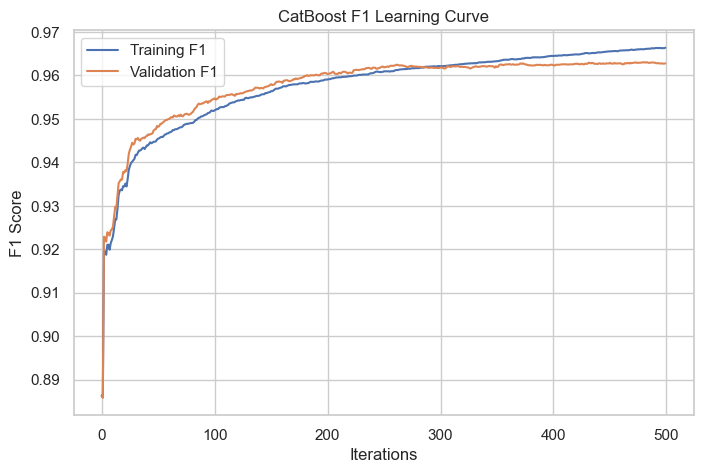

In [25]:
import matplotlib.pyplot as plt

train_metric = evals_result["learn"]["Logloss"]
val_metric = evals_result["validation"]["Logloss"]

plt.figure(figsize=(8, 5))
plt.plot(evals_result["learn"]["F1"], label="Training F1")
plt.plot(evals_result["validation"]["F1"], label="Validation F1")
plt.xlabel("Iterations")
plt.ylabel("F1 Score")
plt.title("CatBoost F1 Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# ============================================================
# 14. HYPERPARAMETER TUNING
# ============================================================
# CatBoost native randomized_search memakai Pool.
# Parameter yang dituning disesuaikan dengan CatBoostClassifier.

param_distributions = {
    "iterations": [500, 800, 1000],
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "depth": [4, 5, 6, 7, 8],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "random_strength": [0.5, 1, 2],
    "bagging_temperature": [0, 0.5, 1],
    "border_count": [64, 128, 254]
}

# Supaya tuning tidak terlalu lama, gunakan sample dari train data.
tuning_sample_size = min(40000, len(X_train_full))

X_tune = X_train_full.sample(
    n=tuning_sample_size,
    random_state=RANDOM_STATE
)

y_tune = y_train_full.loc[X_tune.index]

tune_pool = Pool(
    data=X_tune,
    label=y_tune,
    cat_features=categorical_features
)

tuner = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

search_result = tuner.randomized_search(
    param_distributions=param_distributions,
    X=tune_pool,
    cv=3,
    n_iter=15,
    partition_random_seed=RANDOM_STATE,
    shuffle=True,
    stratified=True,
    refit=True,
    verbose=False
)

best_params = search_result["params"]

print("Best parameters:")
display(best_params)


bestTest = 0.9941781356
bestIteration = 398

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.993347737
bestIteration = 995

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.9939929187
bestIteration = 497

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.9939666495
bestIteration = 327

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.9932292718
bestIteration = 497

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.9938485016
bestIteration = 799

Metric AUC is not calculated on train by default. To ca

{'border_count': 128,
 'bagging_temperature': 0,
 'random_strength': 1,
 'depth': 8,
 'learning_rate': 0.05,
 'l2_leaf_reg': 9,
 'iterations': 800}

In [27]:
# ============================================================
# 15. FINAL MODEL TRAINING
# ============================================================

final_params = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "random_seed": RANDOM_STATE,
    "verbose": 100,
    "allow_writing_files": False,
    **best_params
}

final_model = CatBoostClassifier(**final_params)

final_model.fit(
    train_pool,
    eval_set=valid_pool,
    early_stopping_rounds=50,
    use_best_model=True
)

0:	test: 0.9793297	best: 0.9793297 (0)	total: 58.9ms	remaining: 47s
100:	test: 0.9933933	best: 0.9933933 (100)	total: 6.65s	remaining: 46s
200:	test: 0.9945250	best: 0.9945269 (199)	total: 13.2s	remaining: 39.4s
300:	test: 0.9948965	best: 0.9948965 (300)	total: 19.8s	remaining: 32.9s
400:	test: 0.9950364	best: 0.9950364 (399)	total: 26.6s	remaining: 26.5s
500:	test: 0.9951087	best: 0.9951108 (491)	total: 33.2s	remaining: 19.8s
600:	test: 0.9951449	best: 0.9951450 (598)	total: 39.7s	remaining: 13.2s
700:	test: 0.9951768	best: 0.9951782 (695)	total: 46.5s	remaining: 6.57s
799:	test: 0.9951971	best: 0.9952000 (752)	total: 53.1s	remaining: 0us

bestTest = 0.995200049
bestIteration = 752

Shrink model to first 753 iterations.


CatBoostClassifier(allow_writing_files=False, bagging_temperature=0, border_count=128, depth=8, eval_metric='AUC', iterations=800, l2_leaf_reg=9, learning_rate=0.05, loss_function='Logloss', random_seed=42, random_strength=1, verbose=100)

In [28]:
# ============================================================
# 16. FINAL MODEL EVALUATION
# ============================================================

y_pred = final_model.predict(test_pool).astype(int)
y_proba = final_model.predict_proba(test_pool)[:, 1]

final_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_satisfied": precision_score(y_test, y_pred, pos_label=1),
    "recall_satisfied": recall_score(y_test, y_pred, pos_label=1),
    "f1_satisfied": f1_score(y_test, y_pred, pos_label=1),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

# At-risk passenger = Neutral or Dissatisfied = 0
at_risk_detection_rate = recall_score(y_test, y_pred, pos_label=0)
final_metrics["at_risk_detection_rate"] = at_risk_detection_rate

final_metrics = {
    key: round(value, 4)
    for key, value in final_metrics.items()
}

display(final_metrics)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Neutral or Dissatisfied", "Satisfied"]
))

{'accuracy': 0.9654,
 'precision_satisfied': 0.9739,
 'recall_satisfied': 0.9456,
 'f1_satisfied': 0.9595,
 'roc_auc': 0.9955,
 'at_risk_detection_rate': 0.9805}

                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.96      0.98      0.97     14690
              Satisfied       0.97      0.95      0.96     11286

               accuracy                           0.97     25976
              macro avg       0.97      0.96      0.96     25976
           weighted avg       0.97      0.97      0.97     25976



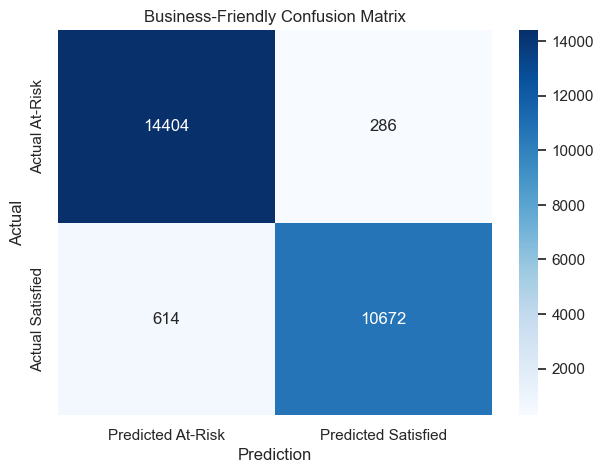

Confusion matrix meaning:
Correctly Identified At-Risk: 14404
Missed At-Risk: 286
False Alert: 614
Correctly Identified Satisfied: 10672


In [29]:
# ============================================================
# 17. BUSINESS-FRIENDLY CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

cm_labels = [
    ["Correctly Identified At-Risk", "Missed At-Risk"],
    ["False Alert", "Correctly Identified Satisfied"]
]

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted At-Risk", "Predicted Satisfied"],
    yticklabels=["Actual At-Risk", "Actual Satisfied"]
)

plt.title("Business-Friendly Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

print("Confusion matrix meaning:")
for i in range(2):
    for j in range(2):
        print(f"{cm_labels[i][j]}: {cm[i, j]}")

,Confidence Level,Percentage
0,High Confidence,92.13
1,Medium Confidence,5.81
2,Low Confidence,2.06


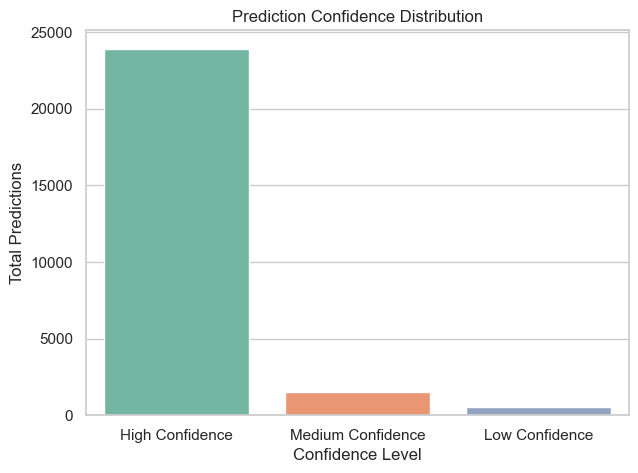

In [30]:
# ============================================================
# 18. PREDICTION CONFIDENCE DISTRIBUTION
# ============================================================

prediction_confidence = np.maximum(y_proba, 1 - y_proba)

confidence_df = pd.DataFrame({
    "prediction_confidence": prediction_confidence
})

confidence_df["confidence_level"] = pd.cut(
    confidence_df["prediction_confidence"],
    bins=[0, 0.60, 0.80, 1.00],
    labels=["Low Confidence", "Medium Confidence", "High Confidence"],
    include_lowest=True
)

confidence_summary = (
    confidence_df["confidence_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

confidence_summary.columns = ["Confidence Level", "Percentage"]

display(confidence_summary)

plt.figure(figsize=(7, 5))
sns.countplot(
    data=confidence_df,
    x="confidence_level",
    order=["High Confidence", "Medium Confidence", "Low Confidence"],
    palette="Set2"
)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence Level")
plt.ylabel("Total Predictions")
plt.show()

In [31]:
# ============================================================
# 19. RECOMMENDATION READINESS SCORE
# ============================================================

high_confidence_rate = (
    confidence_df["confidence_level"]
    .eq("High Confidence")
    .mean()
)

recommendation_readiness_score = (
    (final_metrics["roc_auc"] * 0.35) +
    (final_metrics["f1_satisfied"] * 0.25) +
    (final_metrics["at_risk_detection_rate"] * 0.25) +
    (high_confidence_rate * 0.15)
) * 100

recommendation_readiness_score = round(recommendation_readiness_score, 2)

print("Recommendation Readiness Score:", recommendation_readiness_score)

Recommendation Readiness Score: 97.16


,feature,importance
16,In-flight Wifi Service,22.071008
3,Type of Travel,20.876069
2,Customer Type,7.646709
8,Online Boarding,6.721821
4,Class,5.370542
18,Baggage Handling,4.628698
7,Check-in Service,3.919246
1,Age,3.535970
11,Seat Comfort,3.517281
17,In-flight Entertainment,3.311710


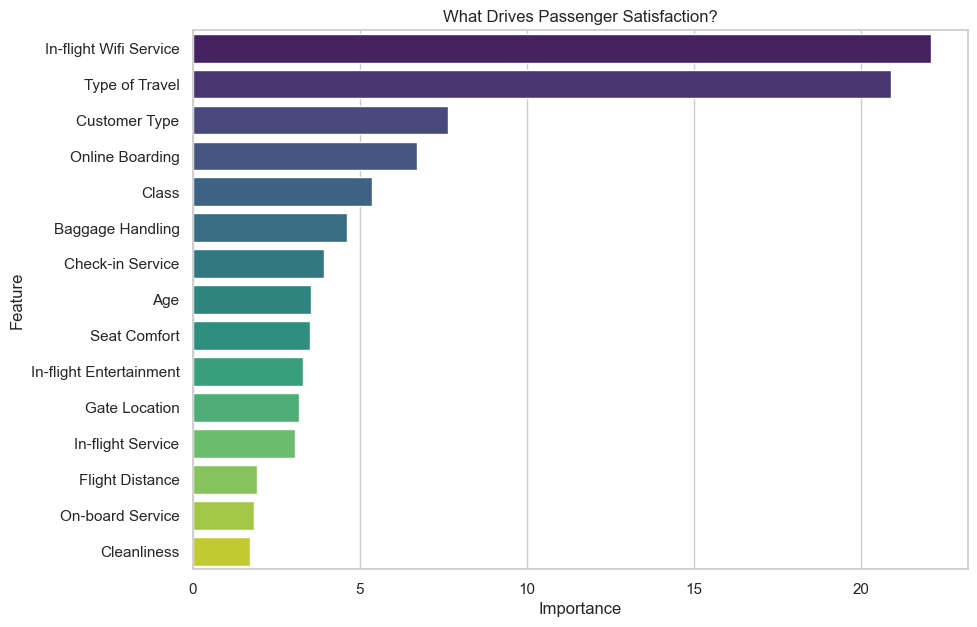

In [32]:
# ============================================================
# 20. FEATURE IMPORTANCE
# ============================================================

feature_importance = final_model.get_feature_importance(
    test_pool,
    type="FeatureImportance"
)

feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": feature_importance
}).sort_values("importance", ascending=False)

display(feature_importance_df.head(15))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance_df.head(15),
    x="importance",
    y="feature",
    palette="viridis"
)

plt.title("What Drives Passenger Satisfaction?")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [33]:
# ============================================================
# 21. SIMPLE PERSONALIZED RECOMMENDATION FUNCTION
# ============================================================

service_recommendation_map = {
    "Online Boarding": "Priority Online Boarding",
    "In-flight Wifi Service": "Wifi Upgrade Package",
    "Seat Comfort": "Seat Comfort Upgrade",
    "Leg Room Service": "Extra Leg Room Offer",
    "In-flight Entertainment": "Entertainment Access Package",
    "Food and Drink": "Meal Upgrade Voucher",
    "Check-in Service": "Fast Check-in Support",
    "Cleanliness": "Cabin Quality Assurance",
    "Baggage Handling": "Priority Baggage Handling",
    "On-board Service": "Premium On-board Assistance",
    "Ease of Online Booking": "Booking Experience Support",
    "Departure and Arrival Time Convenience": "Flexible Schedule Recommendation",
    "Gate Location": "Gate Assistance Notification",
    "In-flight Service": "In-flight Service Recovery"
}

def generate_recommendations(passenger_row, model, top_n=3):
    passenger_df = passenger_row[features].to_frame().T.copy()

    passenger_pool = Pool(
        data=passenger_df,
        cat_features=categorical_features
    )

    satisfied_probability = model.predict_proba(passenger_pool)[0, 1]
    predicted_label = int(satisfied_probability >= 0.5)

    low_service_scores = []

    for col in service_quality_features:
        score = passenger_df[col].iloc[0]

        if score <= 3:
            importance = feature_importance_df.loc[
                feature_importance_df["feature"] == col,
                "importance"
            ].values[0]

            low_service_scores.append({
                "feature": col,
                "score": score,
                "importance": importance,
                "recommendation": service_recommendation_map.get(
                    col,
                    "Service Quality Improvement"
                )
            })

    low_service_scores = sorted(
        low_service_scores,
        key=lambda x: x["importance"],
        reverse=True
    )

    recommendations = low_service_scores[:top_n]

    return {
        "predicted_label": inverse_target_mapping[predicted_label],
        "satisfied_probability": round(float(satisfied_probability), 4),
        "recommendations": recommendations
    }


sample_passenger = X_test.iloc[0]
sample_result = generate_recommendations(sample_passenger, final_model)

sample_result


{'predicted_label': 'Neutral or Dissatisfied',
 'satisfied_probability': 0.0254,
 'recommendations': [{'feature': 'In-flight Wifi Service',
   'score': 3,
   'importance': 22.071007832071555,
   'recommendation': 'Wifi Upgrade Package'},
  {'feature': 'Online Boarding',
   'score': 3,
   'importance': 6.721821404451927,
   'recommendation': 'Priority Online Boarding'},
  {'feature': 'Baggage Handling',
   'score': 3,
   'importance': 4.628698293248831,
   'recommendation': 'Priority Baggage Handling'}]}

In [34]:
# ============================================================
# 22. SIMULATED AFTER-RECOMMENDATION UPLIFT
# ============================================================
# Ini simulasi PoC: fitur layanan yang direkomendasikan dinaikkan menjadi 4
# lalu model memprediksi ulang satisfaction probability.

def simulate_recommendation_uplift(passenger_row, model, top_n=3, improved_score=4):
    before = generate_recommendations(
        passenger_row=passenger_row,
        model=model,
        top_n=top_n
    )

    improved_passenger = passenger_row.copy()

    for rec in before["recommendations"]:
        feature = rec["feature"]
        improved_passenger[feature] = max(
            improved_passenger[feature],
            improved_score
        )

    after = generate_recommendations(
        passenger_row=improved_passenger,
        model=model,
        top_n=top_n
    )

    uplift = after["satisfied_probability"] - before["satisfied_probability"]

    return {
        "before_probability": before["satisfied_probability"],
        "after_probability": after["satisfied_probability"],
        "uplift": round(float(uplift), 4),
        "recommendations": before["recommendations"]
    }


uplift_result = simulate_recommendation_uplift(
    passenger_row=X_test.iloc[0],
    model=final_model
)

uplift_result


{'before_probability': 0.0254,
 'after_probability': 0.3951,
 'uplift': 0.3697,
 'recommendations': [{'feature': 'In-flight Wifi Service',
   'score': 3,
   'importance': 22.071007832071555,
   'recommendation': 'Wifi Upgrade Package'},
  {'feature': 'Online Boarding',
   'score': 3,
   'importance': 6.721821404451927,
   'recommendation': 'Priority Online Boarding'},
  {'feature': 'Baggage Handling',
   'score': 3,
   'importance': 4.628698293248831,
   'recommendation': 'Priority Baggage Handling'}]}

In [ ]:
# ============================================================
# 23. SAVE DEPLOYMENT ARTIFACTS
# ============================================================

models_dir = Path("../models")
reports_dir = Path("../reports")

if not models_dir.exists():
    models_dir = Path("models")

if not reports_dir.exists():
    reports_dir = Path("reports")

models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "catboost_satisfaction_model.cbm"
metadata_path = models_dir / "model_metadata.json"
feature_importance_path = models_dir / "feature_importance.csv"
metrics_path = models_dir / "model_metrics.json"
sample_test_path = models_dir / "sample_passengers.csv"

final_model.save_model(model_path)

feature_importance_df.to_csv(feature_importance_path, index=False)

with open(metrics_path, "w") as f:
    json.dump(final_metrics, f, indent=4)

metadata = {
    "model_name": "catboost_satisfaction_model",
    "model_type": "CatBoostClassifier",
    "target_column": target_col,
    "target_mapping": target_mapping,
    "inverse_target_mapping": inverse_target_mapping,
    "features": features,
    "customer_features": customer_features,
    "service_quality_features": service_quality_features,
    "operational_features": operational_features,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "best_params": best_params,
    "final_metrics": final_metrics,
    "recommendation_readiness_score": recommendation_readiness_score,
    "high_confidence_rate": round(float(high_confidence_rate), 4),
    "model_path": str(model_path),
    "feature_importance_path": str(feature_importance_path)
}

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

sample_passengers = X_test.copy()
sample_passengers["actual_satisfaction"] = y_test.map(inverse_target_mapping)
sample_passengers["predicted_satisfaction"] = [
    inverse_target_mapping[int(pred)] for pred in y_pred
]
sample_passengers["satisfied_probability"] = y_proba.round(4)

sample_passengers.head(200).to_csv(sample_test_path, index=False)

print("Artifacts saved:")
print("Model:", model_path)
print("Metadata:", metadata_path)
print("Metrics:", metrics_path)
print("Feature importance:", feature_importance_path)
print("Sample passengers:", sample_test_path)


Artifacts saved:
Model: ..\models\catboost_satisfaction_model.cbm
Metadata: ..\models\model_metadata.json
Metrics: ..\reports\model_metrics.json
Feature importance: ..\reports\feature_importance.csv
Sample passengers: ..\models\sample_passengers.csv


In [36]:
# ============================================================
# 24. DEPLOYMENT ARTIFACT LOADING TEST
# ============================================================

loaded_model = CatBoostClassifier()
loaded_model.load_model(model_path)

with open(metadata_path, "r") as f:
    loaded_metadata = json.load(f)

sample_input = X_test.iloc[[0]]

sample_pool = Pool(
    data=sample_input[loaded_metadata["features"]],
    cat_features=loaded_metadata["categorical_features"]
)

sample_probability = loaded_model.predict_proba(sample_pool)[0, 1]
sample_prediction = int(sample_probability >= 0.5)

print("Loaded model prediction:")
print("Predicted label:", loaded_metadata["inverse_target_mapping"][str(sample_prediction)])
print("Satisfied probability:", round(float(sample_probability), 4))


Loaded model prediction:
Predicted label: Neutral or Dissatisfied
Satisfied probability: 0.0254
